# Magnetic field of a current loop

In this notebook we compute and visualize the magnetic field of a circular
current loop using the Biot-Savart law.

We will plot the field in the $xz$-plane — the plane that contains the
loop axis. This plane has a reflection symmetry of the loop, so the
$y$-component of $\mathbf{B}$ is zero everywhere in it. We can therefore
fully describe the field using only $B_x$ and $B_z$.

In [2]:
import numpy as np
from scipy import constants
import matplotlib.pyplot as plt

## 2. Biot-Savart functions

We represent the loop as an inscribed polygon of $N$ chord segments.
The vertices lie on the circle; `dl_vectors` and `source_positions`
are derived from the chord endpoints $A$ and $B$:

$$d\boldsymbol{\ell} = B - A, \qquad \text{source} = \frac{A+B}{2}$$

The Biot-Savart law for each segment is

$$d\mathbf{B} = \frac{\mu_0 I}{4\pi}\,
\frac{d\boldsymbol{\ell}\times\mathbf{r}}{|\mathbf{r}|^3}$$

where $\mathbf{r}$ points from the source position to the field point.

In [3]:
def loop_segments(R, N):
    """
    Return source positions and dl vectors for a circular loop of
    radius R in the z=0 plane, approximated by N chord segments.
    The loop carries current counterclockwise when viewed from +z.

    Parameters
    ----------
    R : float  -- loop radius (m)
    N : int    -- number of segments

    Returns
    -------
    source_positions : ndarray, shape (N, 3)
    dl_vectors       : ndarray, shape (N, 3)
    """
    # Place N vertices equally spaced around the circle
    phi_vertices = np.linspace(0, 2 * np.pi, N, endpoint=False)
    vertices = np.column_stack([
        R * np.cos(phi_vertices),
        R * np.sin(phi_vertices),
        np.zeros(N)
    ])

    # Each segment runs from vertex i to vertex i+1 (counterclockwise).
    # np.roll shifts the array by -1, so B[i] = vertices[i+1].
    A = vertices
    B = np.roll(vertices, -1, axis=0)

    dl_vectors       = B - A          # chord vector for each segment
    source_positions = (A + B) / 2    # midpoint of each chord

    return source_positions, dl_vectors


In [4]:
def calculate_magnetic_field(source_positions, dl_vectors, I, field_point):
    """
    Calculate the magnetic field at a single point by summing the
    Biot-Savart contributions from all segments.

    Parameters
    ----------
    source_positions : array_like, shape (N, 3)  -- segment midpoints (m)
    dl_vectors       : array_like, shape (N, 3)  -- chord vectors (m)
    I                : float                     -- current (A)
    field_point      : array_like, shape (3,)    -- evaluation point (m)

    Returns
    -------
    B_vector : ndarray, shape (3,)  -- magnetic field (T)
    """
    source_positions = np.asarray(source_positions, dtype=float)
    dl_vectors       = np.asarray(dl_vectors,       dtype=float)
    field_point      = np.asarray(field_point,      dtype=float)

    B_vector = np.zeros(3)

    for i in range(len(source_positions)):
        # Displacement from source segment to field point
        r_vec = field_point - source_positions[i]
        r_mag = np.linalg.norm(r_vec)

        # Biot-Savart contribution from this segment
        dB = (constants.mu_0 * I / (4 * np.pi)) * \
             np.cross(dl_vectors[i], r_vec) / r_mag**3
        B_vector += dB

    return B_vector


## 3. Loop parameters

Set the physical parameters of the loop and the number of segments
used to approximate it. More segments give a more accurate result
(try changing `N` and see what happens to the plots).

In [5]:
R   = 1.0    # loop radius (m)
I   = 1.0    # current (A)
N   = 3      # number of chord segments

source_positions, dl_vectors = loop_segments(R, N)

# Comparing with found answer
For N=3, I calculated:
$$ B=\frac{\mu_0 I 3 \sqrt{3}}{R\pi} \hat{z} $$
We can use `calculate_magnetic_field` with R = 1 m, I = 1 A, and N=3 to find:

In [6]:
B_vector = calculate_magnetic_field(source_positions, dl_vectors, I, [0,0,0])
print(B_vector)

[0.00000000e+00 0.00000000e+00 2.07846097e-06]


We can then use the same parameters to see if this value agrees with the value calculated by hand:

In [7]:
B = (constants.mu_0 * I * 3 * np.sqrt(3))/(R * np.pi)
print(constants.mu_0)

1.25663706127e-06


## 4. Build the grid

We evaluate the field on a regular grid of points in the $xz$-plane
(i.e. $y = 0$ everywhere).

Points that fall too close to the wire are excluded to avoid the
singularity in the Biot-Savart law (the field of a line current
diverges at the wire). The wire intersects the $xz$-plane at
$(\pm R, 0, 0)$, so we skip any grid point within a distance
`exclusion_radius` of either of those points.

In [8]:
# Grid extent and resolution
grid_max = 2.5 * R
n_points = 20       # grid points along each axis
exclusion_radius = 0.3 * R   # skip points closer than this to the wire

x_vals = np.linspace(-grid_max, grid_max, n_points)
z_vals = np.linspace(-grid_max, grid_max, n_points)
X, Z = np.meshgrid(x_vals, z_vals)

# Arrays to hold Bx and Bz at each grid point
Bx = np.zeros_like(X)
Bz = np.zeros_like(X)

# Wire pierces the xz-plane at (+R, 0, 0) and (-R, 0, 0)
wire_points = np.array([[R, 0.0], [-R, 0.0]])   # (x, z) coordinates

for i in range(n_points):
    for j in range(n_points):
        x = X[i, j]
        z = Z[i, j]

        # Check distance to each wire crossing
        too_close = False
        for wx, wz in wire_points:
            if np.sqrt((x - wx)**2 + (z - wz)**2) < exclusion_radius:
                too_close = True
                break

        if too_close:
            # Leave as zero — these points will be blank in the plots
            continue

        field_point = np.array([x, 0.0, z])
        B_vector = calculate_magnetic_field(
            source_positions, dl_vectors, I, field_point
        )
        Bx[i, j] = B_vector[0]
        Bz[i, j] = B_vector[2]

# Magnitude of the in-plane field
B_mag = np.sqrt(Bx**2 + Bz**2)

## 5. The current loop in the $xy$-plane

The loop lives in the $xy$-plane ($z = 0$). Here we draw the actual
chord segments that make up our polygon approximation, so you can see
how well $N$ segments approximate the circle.

Each segment is drawn as a line from vertex $A$ to vertex $B$, with an
arrow showing the current direction. The filled circle at the midpoint
of each segment marks the source position used in the Biot-Savart
calculation.

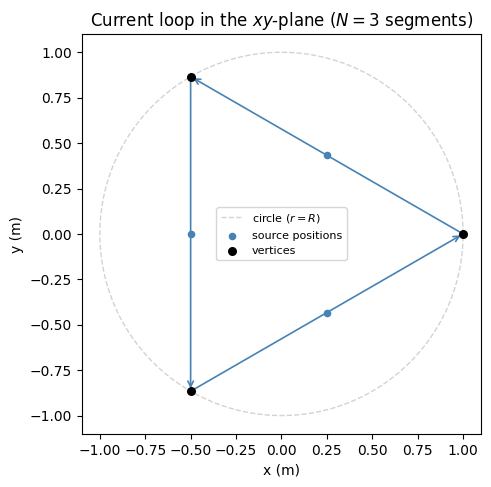

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))

# Recompute vertices so we can draw the segments explicitly
phi_vertices = np.linspace(0, 2 * np.pi, N, endpoint=False)
vertices = np.column_stack([
    R * np.cos(phi_vertices),
    R * np.sin(phi_vertices),
    np.zeros(N)
])
A_pts = vertices
B_pts = np.roll(vertices, -1, axis=0)

# Draw the reference circle
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(R * np.cos(theta), R * np.sin(theta),
        color='lightgray', linewidth=1, linestyle='--',
        label='circle ($r = R$)', zorder=1)

# Draw each chord segment with an arrow at its midpoint
for i in range(N):
    ax.annotate(
        '',
        xy    = (B_pts[i, 0], B_pts[i, 1]),   # arrow tip at B
        xytext= (A_pts[i, 0], A_pts[i, 1]),   # arrow tail at A
        arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2),
        zorder=2,
    )

# Mark source positions (chord midpoints)
ax.scatter(source_positions[:, 0], source_positions[:, 1],
           color='steelblue', s=20, zorder=3,
           label='source positions')

# Mark vertices
ax.scatter(vertices[:, 0], vertices[:, 1],
           color='black', s=30, zorder=4,
           label='vertices')

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title(f'Current loop in the $xy$-plane ($N = {N}$ segments)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Quiver plot

A quiver plot shows the direction and relative magnitude of the field
at each grid point. We normalize the arrows to unit length so the
direction is clear everywhere, and color them by field magnitude
so strong and weak regions are easy to distinguish.

The wire perpendicular to the screen; you can see where it comes out and goes into the screen in the plot.

C:\Users\newmr\AppData\Local\Temp\ipykernel_16564\2102224838.py:10: RuntimeWarning: divide by zero encountered in log10
  log_mag = np.where(B_mag > 0, np.log10(B_mag), np.nan)
C:\Users\newmr\AppData\Local\Temp\ipykernel_16564\2102224838.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


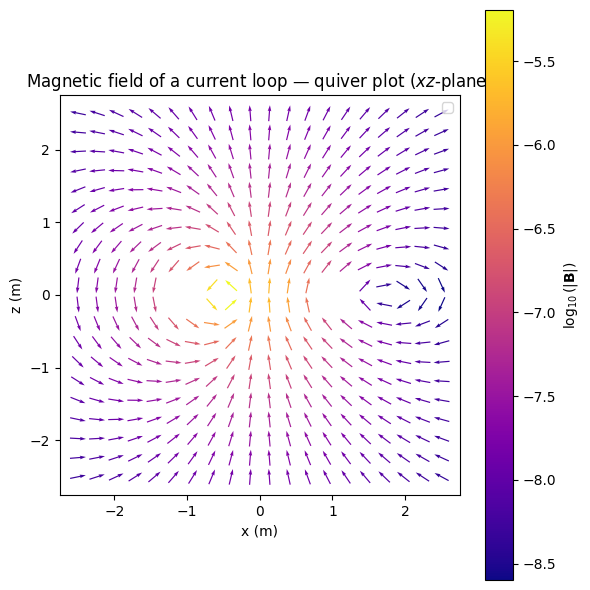

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))

# Normalize arrows to unit length for clarity
# Avoid division by zero at excluded points where B_mag = 0
with np.errstate(invalid='ignore', divide='ignore'):
    Bx_norm = np.where(B_mag > 0, Bx / B_mag, 0)
    Bz_norm = np.where(B_mag > 0, Bz / B_mag, 0)

# Color arrows by log10 of field magnitude for better dynamic range
log_mag = np.where(B_mag > 0, np.log10(B_mag), np.nan)

quiv = ax.quiver(
    X, Z, Bx_norm, Bz_norm,
    log_mag,
    cmap='plasma',
    pivot='mid',
    scale=25,
)
plt.colorbar(quiv, ax=ax, label=r'$\log_{10}(|\mathbf{B}|)$')

ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Magnetic field of a current loop — quiver plot ($xz$-plane)')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Contour plot

A contour plot of $|\mathbf{B}|$ shows where the field is strong and
where it is weak. We again use a logarithmic scale because the field
varies by many orders of magnitude between the region near the wire
and the far field.

Overlaying the quiver arrows on the contours gives a complete picture:
contours show magnitude, arrows show direction.

C:\Users\newmr\AppData\Local\Temp\ipykernel_16564\218841670.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


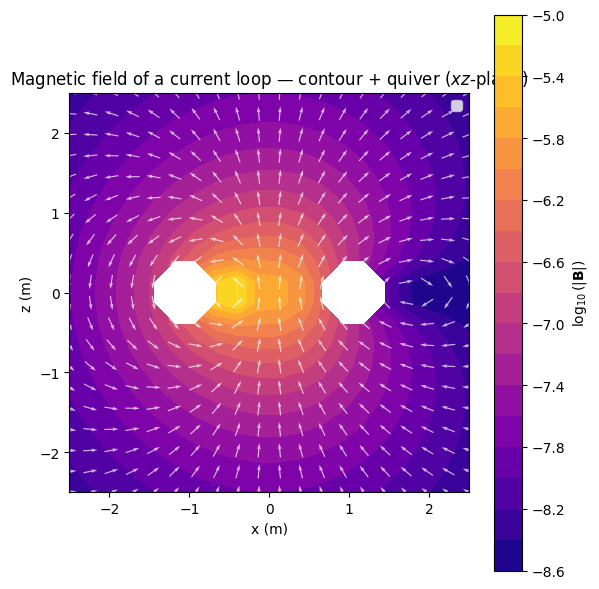

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))

# Filled contours of log field magnitude
cf = ax.contourf(
    X, Z, log_mag,
    levels=20,
    cmap='plasma',
)
plt.colorbar(cf, ax=ax, label=r'$\log_{10}(|\mathbf{B}|)$')

# Overlay normalized quiver arrows
ax.quiver(
    X, Z, Bx_norm, Bz_norm,
    pivot='mid',
    scale=28,
    color='white',
    alpha=0.7,
)

ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_title('Magnetic field of a current loop — contour + quiver ($xz$-plane)')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()